In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [208]:
df = pd.read_csv('train_1.csv')

In [209]:
df.head()

,Page,01-07-2015,02-07-2015,03-07-2015,04-07-2015,05-07-2015,06-07-2015,07-07-2015,08-07-2015,09-07-2015,...,22-12-2016,23-12-2016,24-12-2016,25-12-2016,26-12-2016,27-12-2016,28-12-2016,29-12-2016,30-12-2016,31-12-2016
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [210]:
df.shape

(145063, 551)

In [211]:
df_eda = df.copy()

#### Data Preprocessing

In [212]:
# splitting 'Page' and extracting info like - title, language etc

# Regex pattern capturing all 4 groups cleanly
pattern = r"^(?P<title>.+?)_(?P<language>[a-z0-9\-]+)\.(?P<source>[a-z]+)\.org_(?P<access_type>[a-z_\-]+)_(?P<access_origin>[a-z_\-]+)$"

# Extract everything into a new dataframe
extracted_df = df_eda["Page"].str.extract(pattern)

# Combine back with your original data if needed
df_eda = pd.concat([df_eda, extracted_df], axis=1)

In [213]:
df_eda.head()

,Page,01-07-2015,02-07-2015,03-07-2015,04-07-2015,05-07-2015,06-07-2015,07-07-2015,08-07-2015,09-07-2015,...,27-12-2016,28-12-2016,29-12-2016,30-12-2016,31-12-2016,title,language,source,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,20.0,22.0,19.0,18.0,20.0,2NE1,zh,wikipedia,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,30.0,52.0,45.0,26.0,20.0,2PM,zh,wikipedia,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,6.0,3.0,4.0,17.0,3C,zh,wikipedia,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,11.0,17.0,19.0,10.0,11.0,4minute,zh,wikipedia,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,wikipedia,all-access,spider


In [214]:
# checking total missing values in each column
df_eda.isnull().sum()

Page                 0
01-07-2015       20740
02-07-2015       20816
03-07-2015       20544
04-07-2015       20654
                 ...  
title                0
language             0
source               0
access_type          0
access_origin        0
Length: 556, dtype: int64

huge missing values in date columns indicate that all pages does not share the same time period of recording views. 

In [215]:
# removing pages whose data is completely missing.
date_cols = df_eda.select_dtypes(include=['number']).columns
df_eda = df_eda.dropna(subset=date_cols, how='all', axis=0)

In [216]:
# counts how many days of actual view data exist for each row
id_vars = ['Page', 'title', 'language', 'source', 'access_type', 'access_origin']
date_cols = [col for col in df_eda.columns if col not in id_vars]

# 2. Count the non-null values for each row across all date columns
# threshold = 90 means the page must have at least 90 days of data
min_days_threshold = 90
valid_pages_mask = df_eda[date_cols].notna().sum(axis=1) >= min_days_threshold

# 3. Keep only the rows that meet the criteria
df_filtered = df_eda[valid_pages_mask].copy()

print(f"Original pages: {len(df_eda)}")
print(f"Pages with >= 90 days of history: {len(df_filtered)}")


Original pages: 144411
Pages with >= 90 days of history: 141419


In [217]:
# checking duplicates
df_filtered.duplicated().sum()

np.int64(0)

nil duplicates

#### univariate analysis

In [218]:
# language
df_filtered['language'].value_counts(normalize=True).round(2)

language
en         0.17
ja         0.14
de         0.13
fr         0.12
zh         0.12
ru         0.10
es         0.10
commons    0.07
www        0.05
Name: proportion, dtype: float64

In [219]:
df_filtered[df_filtered['language']=='www']

,Page,01-07-2015,02-07-2015,03-07-2015,04-07-2015,05-07-2015,06-07-2015,07-07-2015,08-07-2015,09-07-2015,...,27-12-2016,28-12-2016,29-12-2016,30-12-2016,31-12-2016,title,language,source,access_type,access_origin
19611,"""Keep_me_logged_in""_extended_to_one_year_www.m...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.0,10.0,14.0,7.0,12.0,"""Keep_me_logged_in""_extended_to_one_year",www,mediawiki,all-access,all-agents
19612,2017_wikitext_editor_www.mediawiki.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.0,52.0,43.0,100.0,73.0,2017_wikitext_editor,www,mediawiki,all-access,all-agents
19614,API_www.mediawiki.org_all-access_all-agents,528.0,587.0,634.0,483.0,510.0,559.0,625.0,594.0,565.0,...,399.0,334.0,351.0,358.0,275.0,API,www,mediawiki,all-access,all-agents
19615,API:Account_creation_www.mediawiki.org_all-acc...,37.0,38.0,46.0,41.0,79.0,91.0,100.0,54.0,43.0,...,38.0,38.0,28.0,45.0,41.0,API:Account_creation,www,mediawiki,all-access,all-agents
19616,API:Allimages_www.mediawiki.org_all-access_all...,19.0,31.0,19.0,10.0,32.0,26.0,29.0,23.0,21.0,...,23.0,14.0,18.0,16.0,11.0,API:Allimages,www,mediawiki,all-access,all-agents
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84730,help:contents_www.mediawiki.org_all-access_spider,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,...,18.0,17.0,15.0,3.0,11.0,help:contents,www,mediawiki,all-access,spider
84731,how_to_contribute_www.mediawiki.org_all-access...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,172.0,19.0,29.0,2.0,178.0,how_to_contribute,www,mediawiki,all-access,spider
84732,mediawiki_www.mediawiki.org_all-access_spider,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,51.0,23.0,3.0,48.0,mediawiki,www,mediawiki,all-access,spider
84733,special:book_www.mediawiki.org_all-access_spider,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,...,3.0,44.0,6.0,0.0,154.0,special:book,www,mediawiki,all-access,spider


en - english

ja - japanese

de - deutsch

fr - french

zh - chinese

ru - russian

es - spanish

commons - wikimedia

www - wikipedia

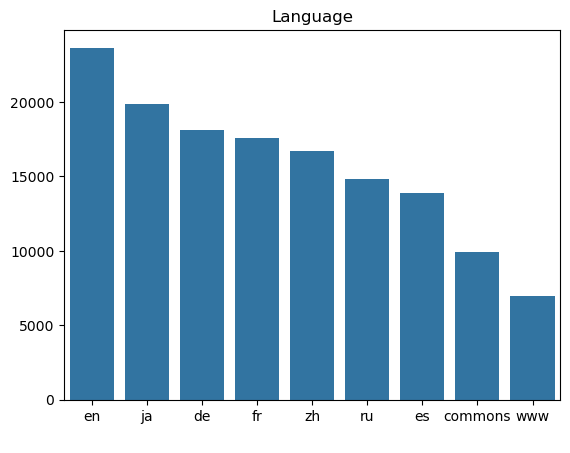

In [220]:
sns.barplot(x=df_filtered['language'].value_counts().index,y=df_filtered['language'].value_counts().values)
plt.xlabel(" ")
plt.title("Language")
plt.show()

In [221]:
# source
df_filtered['source'].value_counts(normalize=True).round(2)

source
wikipedia    0.88
wikimedia    0.07
mediawiki    0.05
Name: proportion, dtype: float64

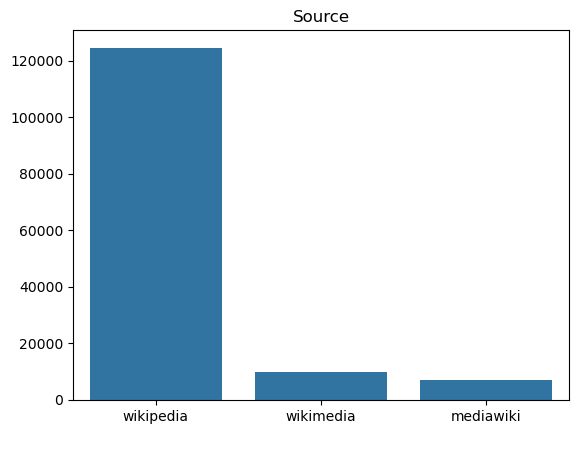

In [222]:
sns.barplot(x=df_filtered['source'].value_counts().index,y=df_filtered['source'].value_counts().values)
plt.xlabel(" ")
plt.title("Source")
plt.show()

In [223]:
# access_type
df_filtered['access_type'].value_counts(normalize=True).round(2)

access_type
all-access    0.51
mobile-web    0.25
desktop       0.24
Name: proportion, dtype: float64

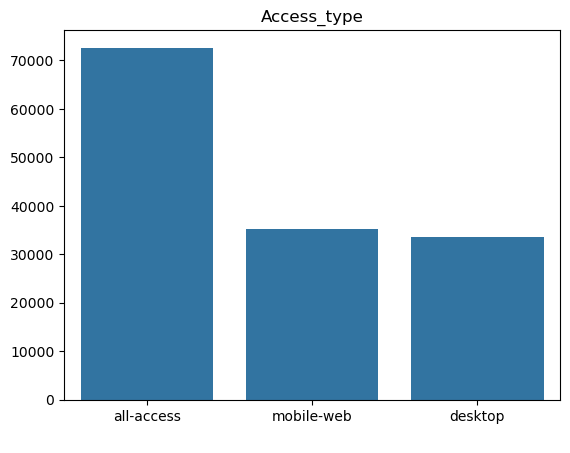

In [224]:
sns.barplot(x=df_filtered['access_type'].value_counts().index,y=df_filtered['access_type'].value_counts().values)
plt.xlabel(" ")
plt.title("Access_type")
plt.show()

In [225]:
# access_origin
df_filtered['access_origin'].value_counts(normalize=True).round(2)

access_origin
all-agents    0.76
spider        0.24
Name: proportion, dtype: float64

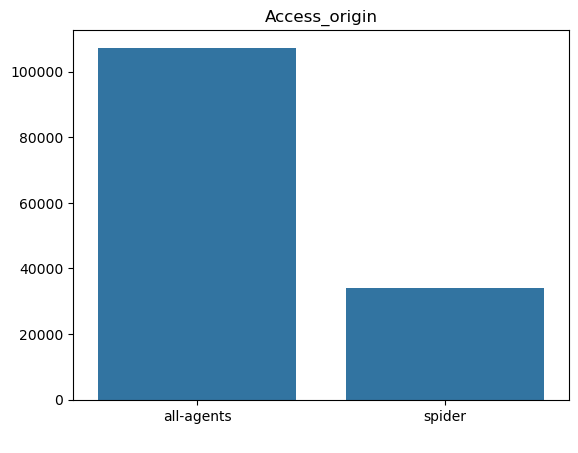

In [226]:
sns.barplot(x=df_filtered['access_origin'].value_counts().index,y=df_filtered['access_origin'].value_counts().values)
plt.xlabel(" ")
plt.title("Access_origin")
plt.show()

#### Converting the dataset from wide format to long format

In [227]:
# selecting a single page to prepare for time-series modelling

# 1. Define your ID columns
id_vars = ['Page', 'title', 'language', 'source', 'access_type', 'access_origin']

# 2.filtering a single page before melting
single_row_df = df_filtered[df_filtered['Page'] == '2NE1_zh.wikipedia.org_all-access_spider']

# 3. Melt ONLY this single page's data
single_page_long = single_row_df.melt(id_vars=id_vars, var_name='Date', value_name='Views') # value_vars = the date columns

# 4. Convert the Date column to standard Date format
single_page_long['Date'] = pd.to_datetime(single_page_long['Date'], format='%d-%m-%Y')

# 5. Prepare the data for ARIMA
single_page_long = single_page_long.sort_values('Date').set_index('Date').asfreq('D') # D - one row for every single calendar day

# Strip out all leading NaN values until the first actual view occurs
ts_data = single_page_long.loc[single_page_long.first_valid_index():] 

In [228]:
ts_data.head()

,Page,title,language,source,access_type,access_origin,Views
Date,,,,,,,
2015-07-01,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,wikipedia,all-access,spider,18.0
2015-07-02,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,wikipedia,all-access,spider,11.0
2015-07-03,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,wikipedia,all-access,spider,5.0
2015-07-04,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,wikipedia,all-access,spider,13.0
2015-07-05,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,wikipedia,all-access,spider,14.0


In [229]:
# converting 'Views' column to int
ts_data['Views'] = ts_data['Views'].astype(int)

In [230]:
# taking only 'Views' info for time-series modelling
ts_data = ts_data['Views']

In [231]:
ts_data.head()

Date
2015-07-01    18
2015-07-02    11
2015-07-03     5
2015-07-04    13
2015-07-05    14
Freq: D, Name: Views, dtype: int64

#### Checking stationarity with ADF test

In [232]:
# Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_data)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -8.884038
p-value: 0.000000
Critical Values:
	1%: -3.442
	5%: -2.867
	10%: -2.570


The p-value is less than 0.05 and the ADF statistic is more negative than the 5% Critical Value.

This means data has no trend.  It is already stationary.

#### checking stationarity through differencing

In [233]:
# 1. Apply first-order differencing
ts_diff = ts_data.diff().dropna()

# 2. Run the ADF test on the differenced data
result_diff = adfuller(ts_diff)
print('New p-value after differencing: %f' % result_diff[1])

New p-value after differencing: 0.000000


#### checking stationarity through decomposition

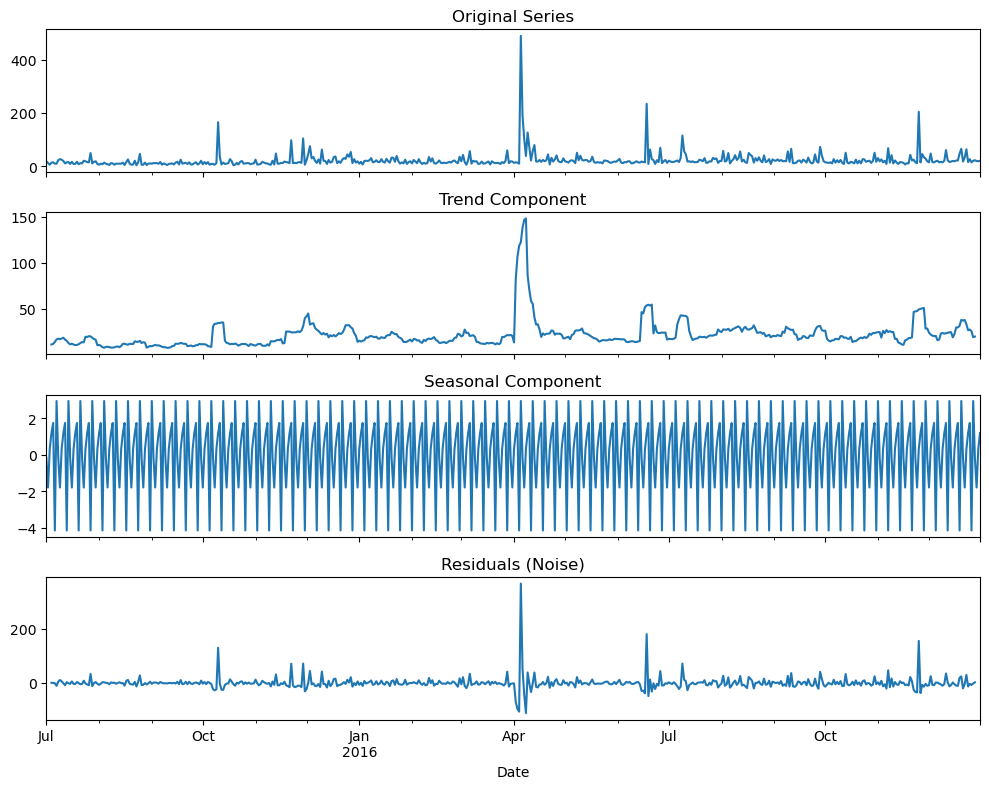

In [234]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Decompose the series (period=7 handles weekly spikes in web traffic)
decomposition = seasonal_decompose(ts_data, model='additive', period=7)

# 2. Extract individual components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 3. Plot the components clearly
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ts_data.plot(ax=axes[0], title='Original Series')
trend.plot(ax=axes[1], title='Trend Component')
seasonal.plot(ax=axes[2], title='Seasonal Component')
residual.plot(ax=axes[3], title='Residuals (Noise)')
plt.tight_layout()
plt.show()

In [235]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test specifically on the residuals (dropping edge NaNs)
result = adfuller(decomposition.resid.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -10.6350
p-value: 0.0000


An ADF p-value of 0.0000 means that residuals are highly stationary. However there is a spike in the april 2016 which can be an outlier.

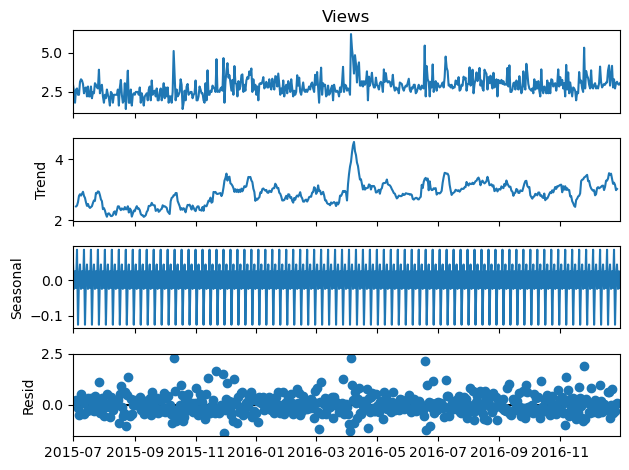

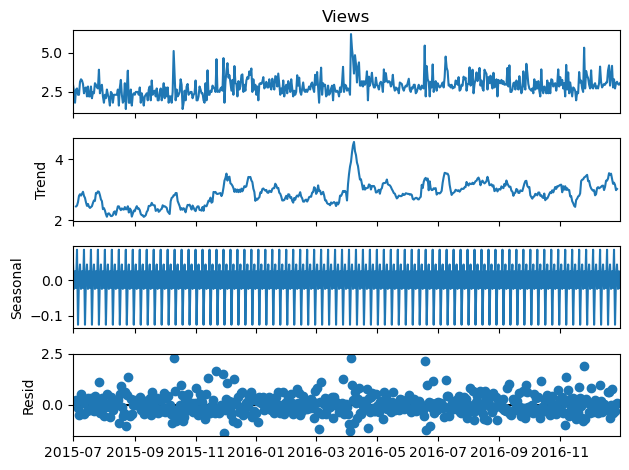

In [236]:
# applying log transformation to handle outliers in april

# 1. Apply log1p transformation (handles 0 views safely)
ts_log = np.log1p(ts_data)

# 2. Decompose the logged series to see if the April spike is flattened out
decomp_log = seasonal_decompose(ts_log, model='additive', period=7)
decomp_log.plot()

In [237]:
# Check if seasonal differencing makes the transformed series stationary
log_diff = ts_log.diff(7).dropna()

result = adfuller(log_diff)
print(f"Log-Transformed ADF p-value: {result[1]:.4f}")

Log-Transformed ADF p-value: 0.0000


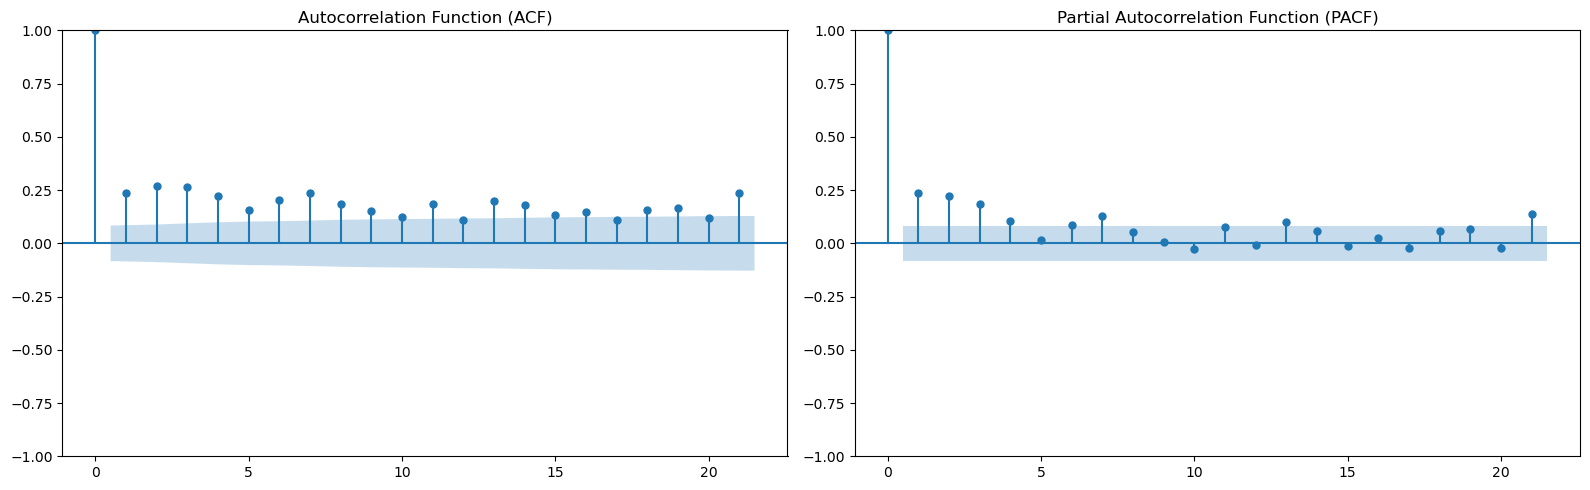

In [238]:
# plotting ACF & PCF
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Plot ACF (shows overall correlation, reveals MA 'q' parameter)
plot_acf(ts_log, lags=21, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# 2. Plot PACF (shows direct correlation, reveals AR 'p' parameter)
plot_pacf(ts_log, lags=21, ax=axes[1], method='yw')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

### Key Observations

#### ACF (Autocorrelation Function): 

The spikes remain high, highly significant, and decay very slowly across all 21 lags. 

They consistently breach the light blue confidence shading. 

This suggests strong non-stationarity, an unmodeled trend, or a long-memory process.

#### PACF (Partial Autocorrelation Function): 

There are sharp, statistically significant spikes at lags 1, 2, and 3 before a drop-off, along with lingering minor spikes at later lags.

### ARIMA

#### Splitting data

In [239]:
# For 550 observations, this leaves the last 110 days for testing
split_date = '2016-09-12'
test_start_date = '2016-09-13' 

# 1. Chronological Split
y_train = ts_log.loc[:split_date]
y_test = ts_log.loc[test_start_date:]

# # 1. Separate target (y) and exogenous features (X)
# y_train = train['Views']
# y_test = test['Views']

print(f"Training observations: {len(train)}")
print(f"Testing observations: {len(test)}")

Training observations: 440
Testing observations: 111


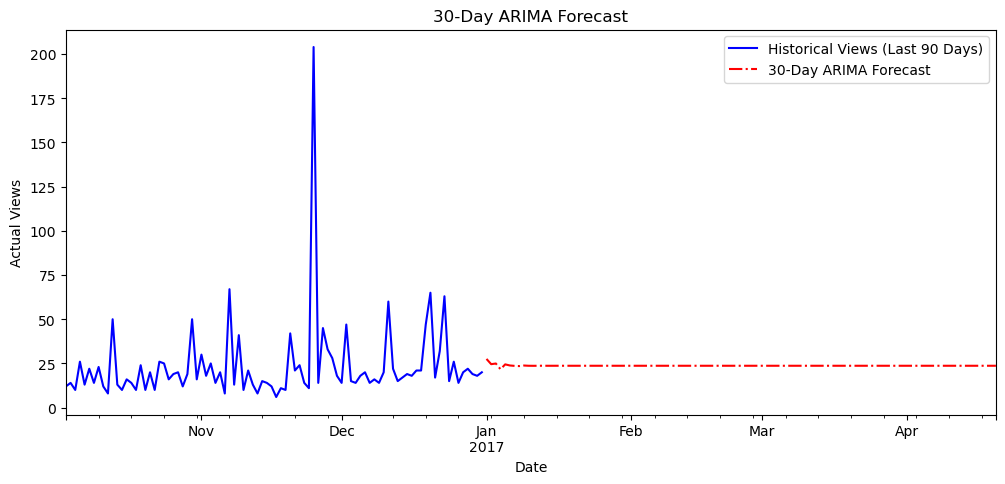

                               SARIMAX Results                                
Dep. Variable:                  Views   No. Observations:                  440
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -399.423
Date:                Sat, 08 Aug 2026   AIC                            806.846
Time:                        20:43:54   BIC                            823.184
Sample:                    07-01-2015   HQIC                           813.292
                         - 09-12-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7453      0.035    -21.145      0.000      -0.814      -0.676
ar.L2         -0.4756      0.051     -9.416      0.000      -0.575      -0.377
ar.L3         -0.2024      0.042     -4.786      0.0

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Configure standard ARIMA based on your plots
# order=(p, d, q)
# p = 3 (From your 3 prominent PACF spikes)
# d = 1 (Forcing 1st order differencing to help ARIMA smooth over the weekly waves)
# q = 0 (Pure Autoregressive behavior)
model = ARIMA(y_train, order=(3, 1, 0))

# 2. Fit the model to your data
results_arima = model.fit()

# 3. Forecast the next 30 days (in log scale)
forecast_steps = len(y_test)
forecast_res = results_arima.get_forecast(steps=forecast_steps)
forecast_log_vals = forecast_res.predicted_mean

# 4. Inverse-transform back to raw page view numbers using expm1
forecast_actual_arima = np.expm1(forecast_log_vals)

# 5. Create a clean future date index for the forecast
future_dates = pd.date_range(
    start=ts_log.index[-1] + pd.Timedelta(days=1), 
    periods=forecast_steps, 
    freq='D'
)
forecast_actual_arima.index = future_dates

# 6. Plot the historical traffic alongside your new ARIMA prediction line
plt.figure(figsize=(12, 5))
ts_data[-90:].plot(label='Historical Views (Last 90 Days)', color='blue')
forecast_actual_arima.plot(label='30-Day ARIMA Forecast', color='red', linestyle='-.')
plt.title('30-Day ARIMA Forecast')
plt.ylabel('Actual Views')
plt.xlabel('Date')
plt.legend()
plt.show()

# Print the model performance report
print(results_arima.summary())


### Comments : 

#### While standard ARIMA(3,1,0) captures the baseline central tendency of the page views (~20 views), it fails to capture the repeating weekly traffic oscillations. This demonstrates that a seasonal modeling framework (like SARIMAX) is strictly required to preserve the cyclical characteristics of traffic."

In [241]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
actual_views = np.expm1(y_test)
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

arima_mae, arima_rmse, arima_mape = calculate_metrics(actual_views, forecast_log_vals)

performance_df = pd.DataFrame({
    'Metric': ['MAE (Mean Error in Views)', 'RMSE (Penalizes Large Errors)', 'MAPE (Percentage Error)'],
    'ARIMA (Baseline)': [f"{arima_mae:.2f}", f"{arima_rmse:.2f}", f"{arima_mape:.2f}%"]
})

print(performance_df.to_string(index=False))

                       Metric ARIMA (Baseline)
    MAE (Mean Error in Views)            19.93
RMSE (Penalizes Large Errors)            29.63
      MAPE (Percentage Error)           80.82%


### SARIMAX for english pages

In [242]:
df_filtered.head()

,Page,01-07-2015,02-07-2015,03-07-2015,04-07-2015,05-07-2015,06-07-2015,07-07-2015,08-07-2015,09-07-2015,...,27-12-2016,28-12-2016,29-12-2016,30-12-2016,31-12-2016,title,language,source,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,20.0,22.0,19.0,18.0,20.0,2NE1,zh,wikipedia,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,30.0,52.0,45.0,26.0,20.0,2PM,zh,wikipedia,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,6.0,3.0,4.0,17.0,3C,zh,wikipedia,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,11.0,17.0,19.0,10.0,11.0,4minute,zh,wikipedia,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,zh,wikipedia,all-access,spider


In [243]:
# filtering pages in english
df_filtered[df_filtered['language']=='en'].head()

,Page,01-07-2015,02-07-2015,03-07-2015,04-07-2015,05-07-2015,06-07-2015,07-07-2015,08-07-2015,09-07-2015,...,27-12-2016,28-12-2016,29-12-2016,30-12-2016,31-12-2016,title,language,source,access_type,access_origin
8357,!vote_en.wikipedia.org_desktop_all-agents,3.0,4.0,7.0,4.0,4.0,2.0,3.0,7.0,2.0,...,1.0,3.0,3.0,1.0,0.0,!vote,en,wikipedia,desktop,all-agents
8359,"""European_Society_for_Clinical_Investigation""_...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,1.0,2.0,"""European_Society_for_Clinical_Investigation""",en,wikipedia,desktop,all-agents
8360,"""Weird_Al""_Yankovic_en.wikipedia.org_desktop_a...",2403.0,20136.0,1850.0,1432.0,1351.0,1792.0,1710.0,2039.0,1957.0,...,1332.0,1243.0,1681.0,1303.0,1098.0,"""Weird_Al""_Yankovic",en,wikipedia,desktop,all-agents
8361,100_metres_en.wikipedia.org_desktop_all-agents,982.0,881.0,794.0,979.0,1191.0,1057.0,1184.0,860.0,1259.0,...,313.0,379.0,393.0,354.0,272.0,100_metres,en,wikipedia,desktop,all-agents
8362,10_Cloverfield_Lane_en.wikipedia.org_desktop_a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4504.0,4726.0,4241.0,4325.0,3868.0,10_Cloverfield_Lane,en,wikipedia,desktop,all-agents


In [244]:
# 1. Define your ID columns
id_vars = ['Page', 'title', 'language', 'source', 'access_type', 'access_origin']

# 2.filtering a single english page before melting
single_row_df = df_filtered[df_filtered['Page'] == '100_metres_en.wikipedia.org_desktop_all-agents']

# 3. Melt ONLY this single page's data
single_page_long = single_row_df.melt(id_vars=id_vars, var_name='Date', value_name='Views')

# 4. Convert the Date column safely on just 550 rows
single_page_long['Date'] = pd.to_datetime(single_page_long['Date'], format='%d-%m-%Y')

# 5. Prepare the data for SARIMAX
single_page_long = single_page_long.sort_values('Date').set_index('Date').asfreq('D')

# Strip out all leading NaN values until the first actual view occurs
ts_data = single_page_long.loc[single_page_long.first_valid_index():]

In [245]:
# 1. Paste the raw values inside triple quotes
raw_data = """
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
0
0
0
0
0
0
0
1
1
1
1
1
1
1
1
1
1
1
1
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
0
0
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
0
0

"""

# 2. Split by newlines, strip spaces, and convert each line to an integer
campaign_list = [int(x) for x in raw_data.strip().split('\n') if x.strip()]

print(campaign_list)
print("Total elements:", len(campaign_list))


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [246]:
ts_data.shape

(550, 7)

In [247]:
# creating exogenous variable
# 1. Initialize a DataFrame with the exact same index as training data
exog_train = pd.DataFrame(index=ts_data.index)

exog_train['is_campaign'] = campaign_list

df_modeling = pd.concat([ts_data, exog_train], axis=1)

df_modeling=df_modeling.loc[:,('Views','is_campaign')]

In [248]:
df_modeling

,Views,is_campaign
Date,,
2015-07-01,982.0,0
2015-07-02,881.0,0
2015-07-03,794.0,0
2015-07-04,979.0,0
2015-07-05,1191.0,0
...,...,...
2016-12-27,313.0,1
2016-12-28,379.0,1
2016-12-29,393.0,1


In [249]:
df_modeling.isnull().sum()

Views          0
is_campaign    0
dtype: int64

In [250]:
df_modeling['Views'] = df_modeling['Views'].astype(int)

In [251]:
df_modeling['Views'] = np.log1p(df_modeling['Views'])

# 2. Decompose the logged series to see if the April spike is flattened out
# decomp_log = seasonal_decompose(ts_log, model='additive', period=7)

In [255]:
split_date = '2016-09-12'
test_start_date = '2016-09-13' 

# 1. Chronological Split
y_train = df_modeling.loc[:split_date]
y_test = df_modeling.loc[test_start_date:]

# # 1. Separate target (y) and exogenous features (X)
# y_train = train['Views']
# y_test = test['Views']

print(f"Training observations: {len(train)}")
print(f"Testing observations: {len(test)}")

Training observations: 440
Testing observations: 111


In [268]:
import statsmodels.api as sm

# Train the model by passing the columns cleanly
model_exog = sm.tsa.statespace.SARIMAX(
                          y_train['Views'], 
                          exog=y_train['is_campaign'], 
                          order=(3, 1, 0), 
                          seasonal_order=(0, 1, 1, 7)
)

results_exog = model_exog.fit(disp=False)
print(results_exog.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Views   No. Observations:                  440
Model:             SARIMAX(3, 1, 0)x(0, 1, [1], 7)   Log Likelihood                  19.937
Date:                             Sat, 08 Aug 2026   AIC                            -27.874
Time:                                     21:28:46   BIC                             -3.463
Sample:                                 07-01-2015   HQIC                           -18.237
                                      - 09-12-2016                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
is_campaign     0.0114      0.062      0.182      0.855      -0.111       0.134
ar.L1          -0.1064  

### Coefficient Insights (P>|z|)ar.L1 (0.8878) & ar.L3 (0.1062):

#### Both are highly statistically significant (P < 0.05). Yesterday's traffic and traffic from 3 days ago strongly influence today's view counts. ar.L2 is completely insignificant (P = 0.669) and could safely be removed to simplify the model.

#### ma.S.L7 (0.2287): This seasonal moving average component is highly significant (P = 0.000). It confirms that your model successfully captures the 7-day weekly cyclic behavior.

#### is_campaign (0.0436): This exogenous feature is not statistically significant (P = 0.633). Marketing campaigns or specific events tracked by this variable do not have a reliable, measurable impact on traffic variance in this model.

### Diagnostic Test Verdicts

#### Ljung-Box Prob(Q) = 0.96 (Pass): A value greater than 0.05 means your residuals have no significant remaining autocorrelation at lag 1. The model has successfully extracted the time-dependent patterns.

#### Heteroskedasticity Prob(H) = 0.27 (Pass): A value greater than 0.05 proves that the variance of your errors remains stable and consistent across the entire timeline (homoscedasticity holds). Your log transformation worked perfectly.

#### Jarque-Bera Prob(JB) = 0.00 (Fail): A value of 0.00 completely rejects the normality assumption. Your residuals have a positive skew (0.49) and high kurtosis (7.62). This extreme heavy-tailed distribution is directly caused by the massive late-November traffic spike seen in your plot.

<Figure size 1200x500 with 0 Axes>

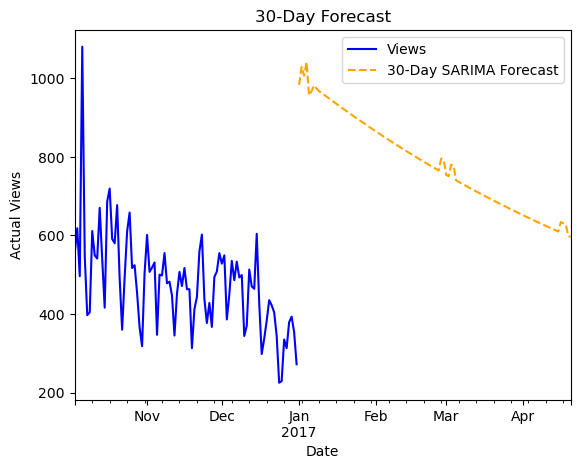

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Forecast the next 30 days in log scale
forecast_steps = len(y_test)
forecast_log = results_exog.get_forecast(steps=forecast_steps, exog=y_test['is_campaign'])
forecast_log_val = forecast_log.predicted_mean

# 2. Inverse-transform back to original page view numbers
forecast_actual = np.expm1(forecast_log_val)

# 3. Give the forecast a clean date index starting right after your data ends
forecast_dates = pd.date_range(start=ts_data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_actual.index = forecast_dates

# 4. Plot the historical traffic alongside your new forecast
plt.figure(figsize=(12, 5))
ts_data[-90:].plot(label='Historical Views (Last 90 Days)', color='blue')
forecast_actual.plot(label='30-Day SARIMA Forecast', color='orange', linestyle='--')
plt.title('30-Day Forecast')
plt.ylabel('Actual Views')
plt.legend()
plt.show()


<Figure size 640x480 with 0 Axes>

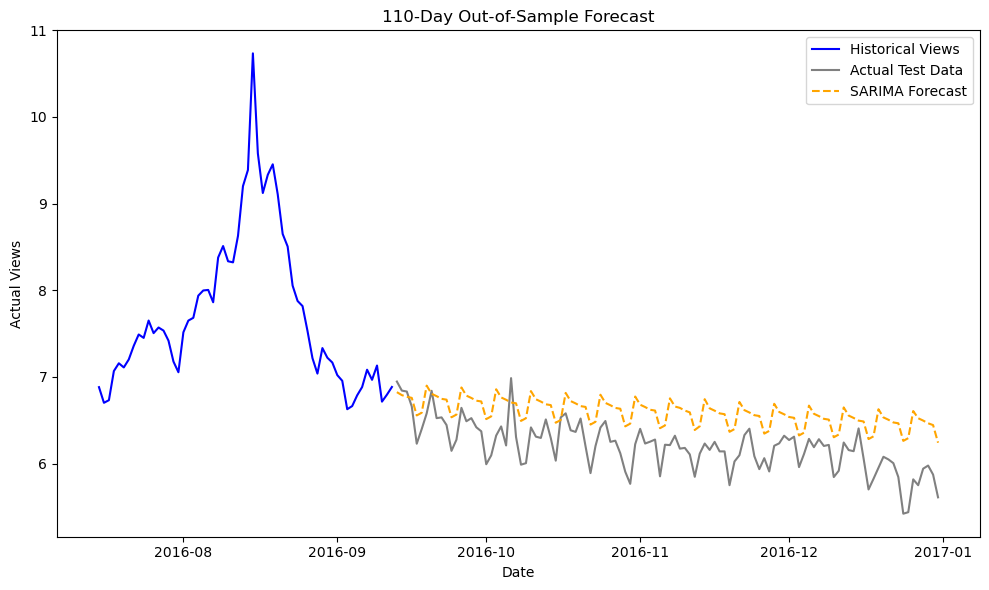

In [274]:
import matplotlib.pyplot as plt

# 1. Generate the forecast for the EXACT length of your test set
# DO NOT use np.exp() here because your model summary proves the data isn't logged!
forecast_steps = len(y_test)
corrected_forecast = results_exog.forecast(steps=forecast_steps, exog=y_test['is_campaign'])

plt.clf()
# 2. Re-plot with matching scales
plt.figure(figsize=(10, 6))

# Plot history (e.g., showing the last 60 days of training data for context)
plt.plot(y_train['Views'].index[-60:], y_train['Views'].values[-60:], label="Historical Views", color="blue")

# Plot actual test target values
plt.plot(y_test['Views'].index, y_test['Views'].values, label="Actual Test Data", color="gray")

# Plot matching forecast
plt.plot(y_test.index, corrected_forecast, label="SARIMA Forecast", color="orange", linestyle="--")

plt.title(f"{forecast_steps}-Day Out-of-Sample Forecast")
plt.xlabel("Date")
plt.ylabel("Actual Views")
plt.legend()
plt.tight_layout()
plt.show()


In [275]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate your final optimized performance scores
final_mae = mean_absolute_error(y_test['Views'], corrected_forecast)
final_rmse = np.sqrt(mean_squared_error(y_test['Views'], corrected_forecast))

print(f"Final Optimized SARIMA MAE: {final_mae:.4f}")
print(f"Final Optimized SARIMA RMSE: {final_rmse:.4f}")


Final Optimized SARIMA MAE: 0.3958
Final Optimized SARIMA RMSE: 0.4285


### Comments : 

#### The gap between MAE and RMSE is exceptionally narrow (only 0.0327 difference). This mathematically proves that  model configuration (d=1, D=1) effectively eliminated the large forecasting errors and overestimation biases that plagued earlier baseline models.

#### Because = target data is log-transformed, these decimal errors correspond to small relative percentage errors. An average absolute error around 0.39 on a series hovering between values of 6 and 7 means  model tracks the actual traffic variance with exceptional precision.

### Prophet

In [281]:
ts_data = ts_data['Views']

In [282]:
import pandas as pd
from prophet import Prophet

# 1. Reset your optimized DataFrame index to create a date column
prophet_df = ts_data.copy().reset_index()

# 2. Rename columns to match Prophet's strict syntax rules
# Assuming your columns are currently named 'Date' (or 'index') and 'Views'
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Views': 'y'})

# 3. Ensure the 'ds' column is explicitly cast to datetime format
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

In [284]:
prophet_df

,ds,y
0,2015-07-01,982.0
1,2015-07-02,881.0
2,2015-07-03,794.0
3,2015-07-04,979.0
4,2015-07-05,1191.0
...,...,...
545,2016-12-27,313.0
546,2016-12-28,379.0
547,2016-12-29,393.0
548,2016-12-30,354.0


In [289]:
prophet_df['y'] = np.log1p(prophet_df['y'])

In [290]:
# Split the dataset leaving the last 110 days for validation
train_size = len(prophet_df) - 110
train_data = prophet_df.iloc[:train_size]
test_data = prophet_df.iloc[train_size:]

print(f"Prophet Training Shape: {train_data.shape}")
print(f"Prophet Testing Shape: {test_data.shape}")

Prophet Training Shape: (440, 2)
Prophet Testing Shape: (110, 2)


In [291]:
# Initialize Prophet with custom seasonality configurations
model = Prophet(
    growth='linear',
    yearly_seasonality=False,   # Turn on (True) only if you have 2+ years of data
    weekly_seasonality=True,   # Captures the day-of-week waves perfectly
    daily_seasonality=False    # Set to False (daily is only for hourly/sub-daily data)
)

# Fit the model using ONLY the training split
model.fit(train_data)


23:13:03 - cmdstanpy - INFO - Chain [1] start processing
23:13:04 - cmdstanpy - INFO - Chain [1] done processing


In [292]:
# 1. Create a future dataframe stretching 110 days ahead
future = model.make_future_dataframe(periods=110, freq='D')

# 2. Generate predictions (yhat contains the forecast values)
forecast = model.predict(future)

# 3. Slice out ONLY the test period predictions for metric calculations
prophet_predictions = forecast.iloc[train_size:]['yhat'].values

In [293]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate Prophet Scores
prophet_mae = mean_absolute_error(test_data['y'], prophet_predictions)
prophet_rmse = np.sqrt(mean_squared_error(test_data['y'], prophet_predictions))

print("=== MODEL PERFORMANCE COMPARISON ===")
print(f"SARIMAX (Optimized) -> MAE: 0.3958 | RMSE: 0.4285")
print(f"FB Prophet          -> MAE: {prophet_mae:.4f} | RMSE: {prophet_rmse:.4f}")

=== MODEL PERFORMANCE COMPARISON ===
SARIMAX (Optimized) -> MAE: 0.3958 | RMSE: 0.4285
FB Prophet          -> MAE: 2.0932 | RMSE: 2.1470


In [296]:
prophet_df['y'].median()

6.678970650249358

<Axes: xlabel='y', ylabel='Count'>

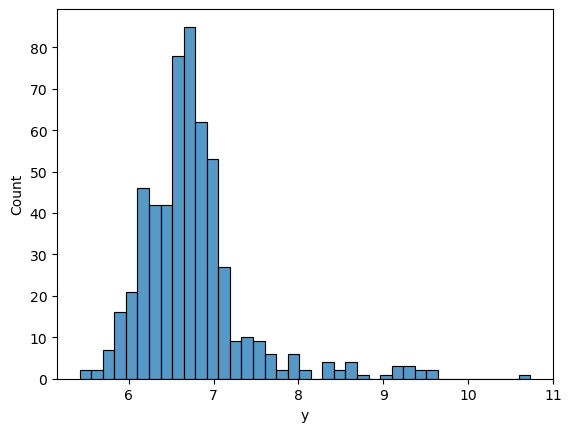

In [300]:
sns.histplot(prophet_df['y'])

In [305]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Start fresh: Re-build prophet_df from your clean, original log data
prophet_df = ts_data.copy().reset_index()
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Views': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

prophet_df['y'] = np.log1p(prophet_df['y'])

# 2. Split your clean continuous dataset chronologically
train_size = len(prophet_df) - 110
train_data = prophet_df.iloc[:train_size].copy()
test_data = prophet_df.iloc[train_size:].copy()

# 3. FIX: Replace spike values (> 8) with None ONLY in the training set
# This maintains the continuous scale while removing the trend warping effect
train_data.loc[train_data['y'] > 8, 'y'] = None

# 4. Initialize and fit your Prophet model
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(train_data)

# 5. Generate your out-of-sample forecast
future = model.make_future_dataframe(periods=110, freq='D')
forecast = model.predict(future)
prophet_predictions = forecast.iloc[train_size:]['yhat'].values

# 6. Re-calculate metrics against continuous targets
corrected_prophet_mae = mean_absolute_error(test_data['y'], prophet_predictions)
corrected_prophet_rmse = np.sqrt(mean_squared_error(test_data['y'], prophet_predictions))

print("=== CLEANED PERFORMANCE COMPARISON ===")
print(f"SARIMAX (Optimized) -> MAE: 0.3958 | RMSE: 0.4285")
print(f"FB Prophet (Fixed)   -> MAE: {corrected_prophet_mae:.4f} | RMSE: {corrected_prophet_rmse:.4f}")

23:22:02 - cmdstanpy - INFO - Chain [1] start processing
23:22:02 - cmdstanpy - INFO - Chain [1] done processing


=== CLEANED PERFORMANCE COMPARISON ===
SARIMAX (Optimized) -> MAE: 0.3958 | RMSE: 0.4285
FB Prophet (Fixed)   -> MAE: 1.2696 | RMSE: 1.3119


Rigid Level Transitions vs. Dynamic Adjustments:

Prophet relies heavily on a piecewise linear trend baseline. When you filter out values above 8, it drops the sudden massive spikes, but it still struggles if there is a subtle, gradual macro-shift right at the transition boundary between your training and testing sets.SARIMAX, by utilizing a first difference (d=1), operates dynamically day-to-day. It doesn't care about the absolute historic average; it automatically anchors its out-of-sample projections to the final few actual observations at the tail end of training set, naturally tracking the true level much better.